Excel 中的 sheet: ['玉米加权']

原始数据形状: (1996, 10)
原始列名: ['日期', '开盘价', '最高价', '最低价', '收盘价', '成交量', '持仓量', '结算价', '华北小麦替代利润', 'date,open,high,low,close,volume,openint,profit']
          日期   开盘价   最高价   最低价   收盘价     成交量     持仓量   结算价  华北小麦替代利润  \
0 2018-01-10  1819  1826  1817  1823  171831  690364  1821      0.00   
1 2018-01-11  1822  1827  1811  1816  211516  685421  1817   -190.96   
2 2018-01-12  1817  1822  1809  1821  184625  686344  1815   -189.49   

  date,open,high,low,close,volume,openint,profit  
0   2018-01-10,1819,1826,1817,1823,171831,690364  
1   2018-01-11,1822,1827,1811,1816,211516,685421  
2   2018-01-12,1817,1822,1809,1821,184625,686344  

日线数据: 2018-01-10 → 2026-04-07  共 1996 天
周线数据: 2018-01-15 → 2026-04-13  共 427 周
✅ 华北小麦替代利润已加入

特征工程完成，总列数: 30

全部特征 (15):
   1. ret_1w
   2. ret_4w
   3. ret_8w
   4. mom_diff
   5. bias_5
   6. bias_20
   7. vol_4w
   8. vol_8w
   9. range_pct
  10. vol_ratio
  11. oi_chg
  12. oi_chg_4w
  13. wheat_profit
  14. wheat_profit_ma4
  15. 

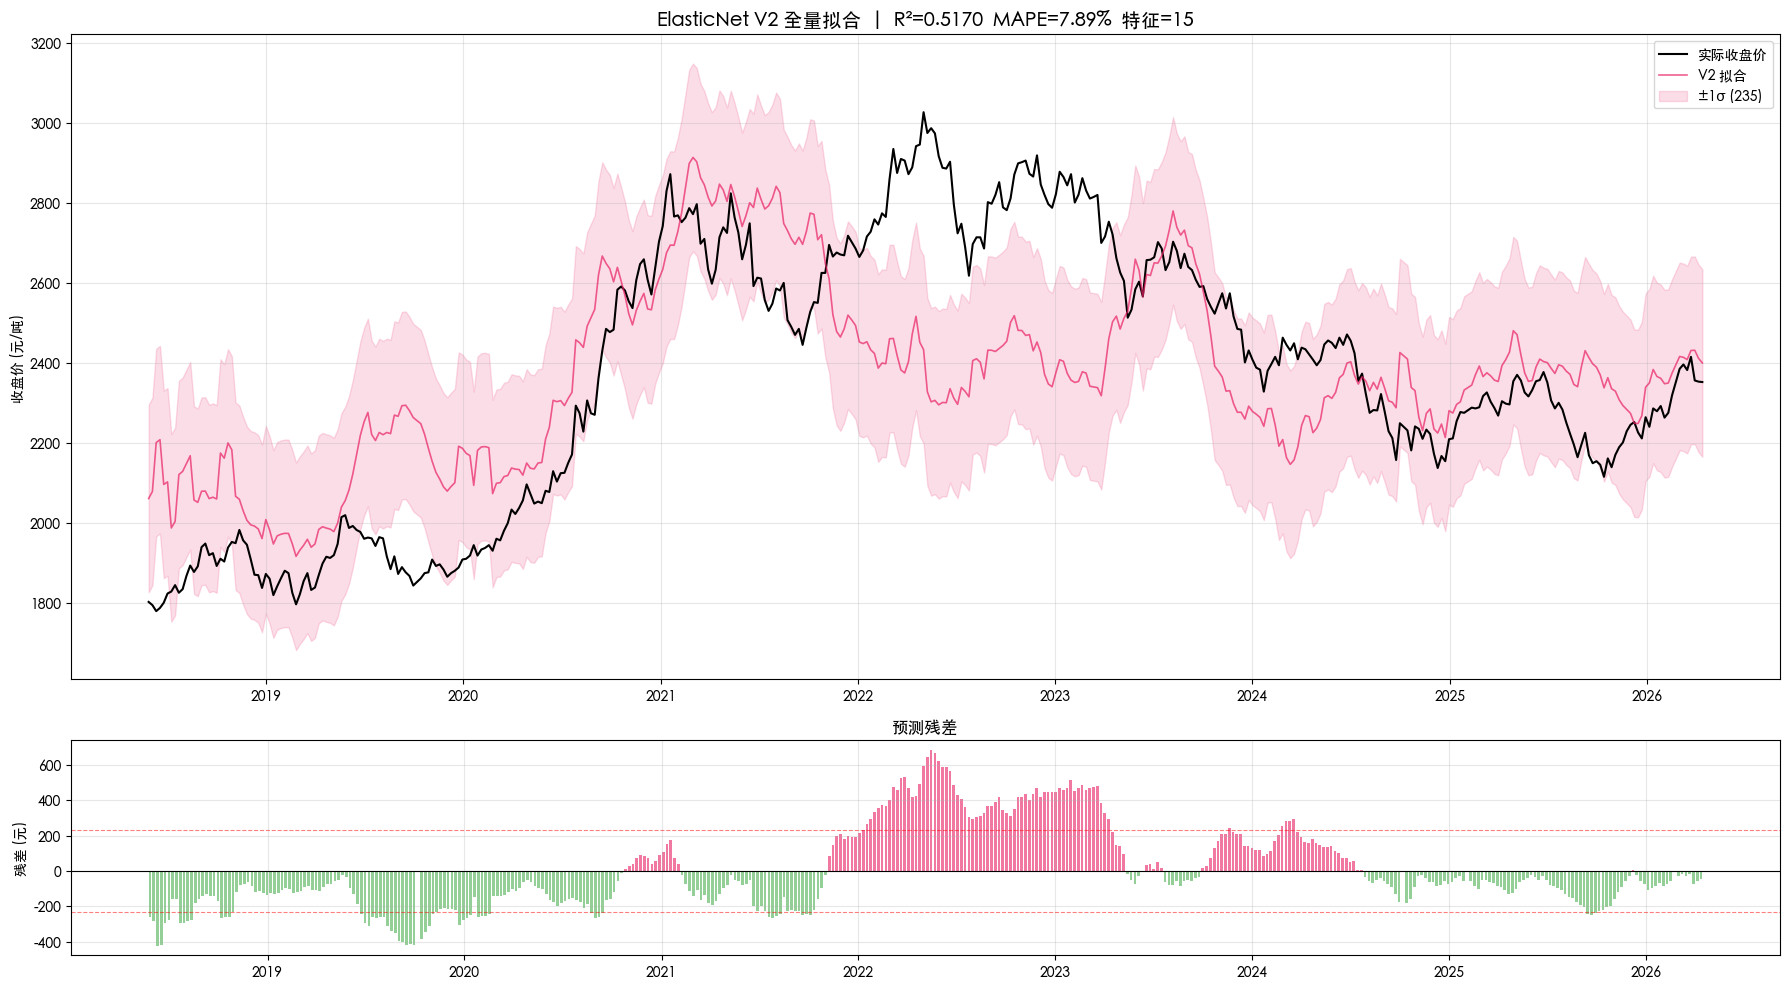

✅ 拟合图已保存: v2_01_fit.png

最新数据日期: 2026-04-13
最新收盘价:   2352.00 元/吨
预测范围: 2026_17 ~ 2026_22


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                📈  ElasticNet V2 — 玉米期货 6 周价格走势预测                              ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┫
┃  模型: ElasticNet  α=16.398587  l1_ratio=1.00                                                            ┃
┃  训练: 408周  R²=0.5170  MAPE=7.89%  σ=±234.6 元/吨                                                         ┃
┃  基准: 2352.00 元/吨 (2026-04-13)                                                                          ┃
┣━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┫
┃ 周次          日期               预测价格      周涨跌     周涨跌%     累计涨跌      累计%            1σ区间            2σ区间         趋势 ┃
┣────────────────────────────────────────────────

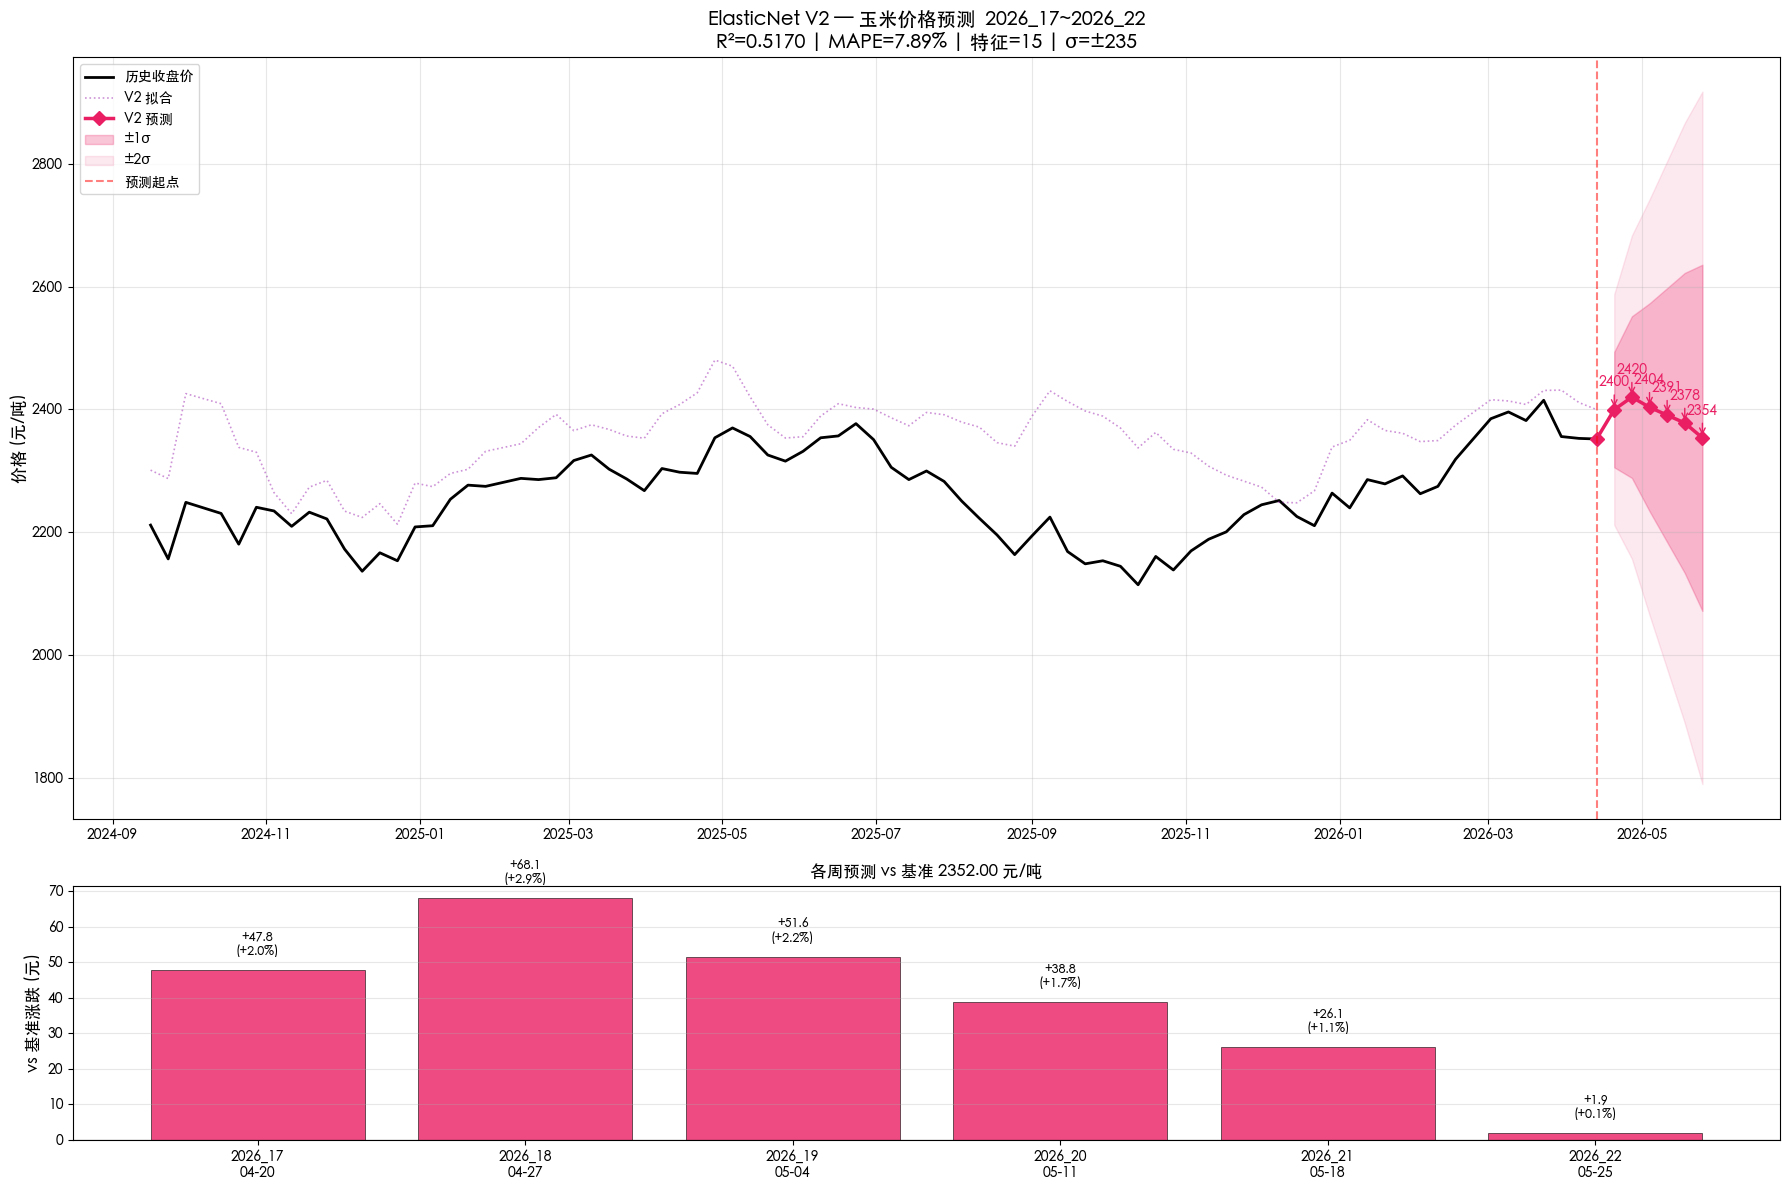

✅ 预测图已保存: v2_02_forecast.png


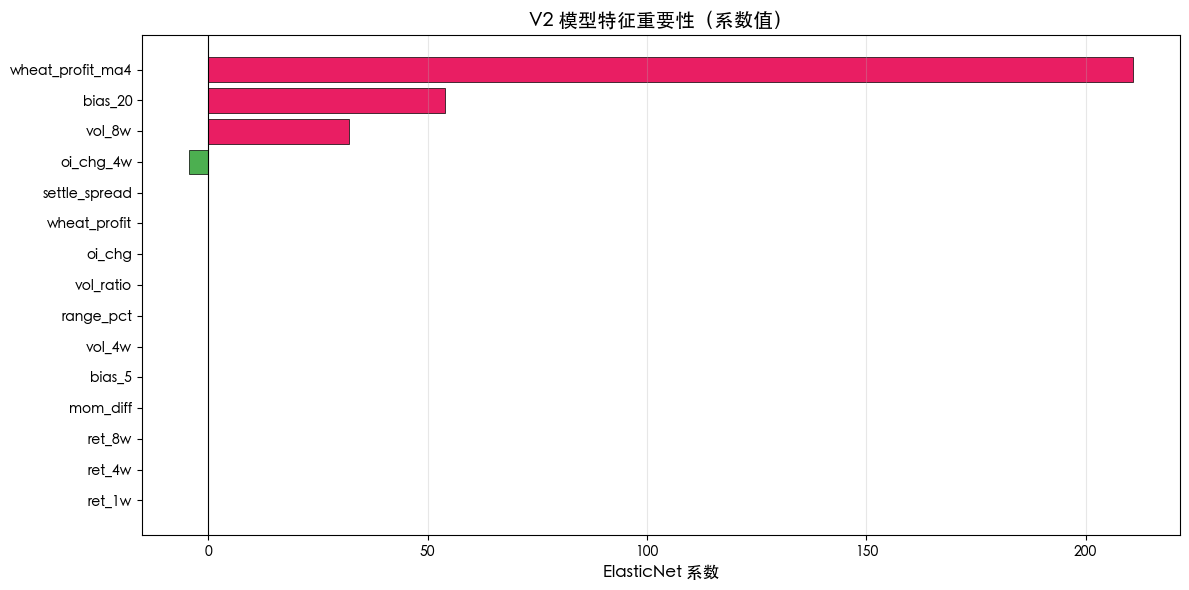

✅ 特征重要性图已保存: v2_03_feature_importance.png

✅ 预测结果已保存: v2_corn_forecast.xlsx

📋 模型摘要:
  alpha      : 16.398587
  l1_ratio   : 1.00
  R²         : 0.5170
  MAE        : 187.54
  MAPE       : 7.89%
  残差 σ     : ±234.62
  训练样本   : 408
  特征数     : 15
  最后日期   : 2026-04-13
  最后价格   : 2352.00

🎉 V2 模型全部运行完毕！


In [1]:
# ============================================================
#  玉米期货价格预测 — ElasticNet V2（完全独立版）
#  预测范围: 2026_10 ~ 2026_15
# ============================================================

import pandas as pd
import numpy as np
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import matplotlib

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.sans-serif'] = ['Heiti TC', 'STHeiti', 'SimHei',
                                           'Songti SC', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False

# ============================================================
#  PART 1：读取数据
# ============================================================

file_path = '玉米加权.xlsx'

sheet_names = pd.ExcelFile(file_path).sheet_names
print(f"Excel 中的 sheet: {sheet_names}")

df_raw = pd.read_excel(file_path, sheet_name='玉米加权')
print(f"\n原始数据形状: {df_raw.shape}")
print(f"原始列名: {list(df_raw.columns)}")
print(df_raw.head(3))

# ============================================================
#  PART 2：数据清洗 & 日线→周线
# ============================================================

col_map = {
    '日期': 'date',
    '开盘价': 'open',
    '最高价': 'high',
    '最低价': 'low',
    '收盘价': 'close',
    '成交量': 'volume',
    '持仓量': 'oi',
    '结算价': 'settle',
    '华北小麦替代利润': 'wheat_profit'
}
df = df_raw.rename(columns=col_map).copy()

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

num_cols = ['open', 'high', 'low', 'close', 'volume', 'oi', 'settle', 'wheat_profit']
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

print(f"\n日线数据: {df['date'].min().strftime('%Y-%m-%d')} → "
      f"{df['date'].max().strftime('%Y-%m-%d')}  共 {len(df)} 天")

agg_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum',
    'oi': 'last',
    'settle': 'last',
}
if 'wheat_profit' in df.columns:
    agg_dict['wheat_profit'] = 'last'

df_w = df.resample('W-MON', on='date').agg(agg_dict).dropna(subset=['close']).reset_index()
df_w = df_w.sort_values('date').reset_index(drop=True)

df_w['year'] = df_w['date'].dt.isocalendar().year.astype(int)
df_w['week'] = df_w['date'].dt.isocalendar().week.astype(int)
df_w['year_week'] = df_w['year'].astype(str) + '_' + df_w['week'].astype(str).str.zfill(2)

print(f"周线数据: {df_w['date'].min().strftime('%Y-%m-%d')} → "
      f"{df_w['date'].max().strftime('%Y-%m-%d')}  共 {len(df_w)} 周")

# ============================================================
#  PART 3：特征工程
# ============================================================

df_f = df_w.copy()

# (a) 动量
df_f['ret_1w'] = df_f['close'].pct_change(1)
df_f['ret_4w'] = df_f['close'].pct_change(4)
df_f['ret_8w'] = df_f['close'].pct_change(8)
df_f['mom_diff'] = df_f['ret_1w'] - df_f['ret_4w']

# (b) 均线偏离
df_f['ma5'] = df_f['close'].rolling(5).mean()
df_f['ma10'] = df_f['close'].rolling(10).mean()
df_f['ma20'] = df_f['close'].rolling(20).mean()
df_f['bias_5'] = (df_f['close'] - df_f['ma5']) / df_f['ma5']
df_f['bias_20'] = (df_f['close'] - df_f['ma20']) / df_f['ma20']

# (c) 波动率
df_f['vol_4w'] = df_f['ret_1w'].rolling(4).std()
df_f['vol_8w'] = df_f['ret_1w'].rolling(8).std()
df_f['range_pct'] = (df_f['high'] - df_f['low']) / df_f['close']

# (d) 量价
df_f['vol_ma5'] = df_f['volume'].rolling(5).mean()
df_f['vol_ratio'] = df_f['volume'] / df_f['vol_ma5']
df_f['oi_chg'] = df_f['oi'].pct_change(1)
df_f['oi_chg_4w'] = df_f['oi'].pct_change(4)

# (e) 华北小麦替代利润
has_wheat = 'wheat_profit' in df_f.columns and df_f['wheat_profit'].notna().sum() > 20
if has_wheat:
    df_f['wheat_profit_ma4'] = df_f['wheat_profit'].rolling(4).mean()
    print("✅ 华北小麦替代利润已加入")
else:
    print("⚠️ 华北小麦替代利润数据不足，跳过")

# (f) 结算价差
if 'settle' in df_f.columns:
    df_f['settle_spread'] = df_f['settle'] - df_f['close']

print(f"\n特征工程完成，总列数: {len(df_f.columns)}")

# ============================================================
#  PART 4：定义特征 & 清洗
# ============================================================

price_features = [
    'ret_1w', 'ret_4w', 'ret_8w', 'mom_diff',
    'bias_5', 'bias_20',
    'vol_4w', 'vol_8w', 'range_pct',
    'vol_ratio', 'oi_chg', 'oi_chg_4w',
]
wheat_features = ['wheat_profit', 'wheat_profit_ma4'] if has_wheat else []
extra_features = ['settle_spread'] if 'settle_spread' in df_f.columns else []

all_features = price_features + wheat_features + extra_features
target_col = 'close'

print(f"\n全部特征 ({len(all_features)}):")
for i, f in enumerate(all_features):
    print(f"  {i+1:2d}. {f}")

df_v2 = df_f.dropna(subset=all_features + [target_col]).reset_index(drop=True)
print(f"\n清洗后样本: {len(df_v2)} 周")
print(f"  范围: {df_v2['date'].min().strftime('%Y-%m-%d')} → "
      f"{df_v2['date'].max().strftime('%Y-%m-%d')}")

X = df_v2[all_features].values
y = df_v2[target_col].values

# ============================================================
#  PART 5：训练 ElasticNet V2
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
    n_alphas=200,
    cv=10,
    max_iter=50000,
    random_state=42,
    n_jobs=-1,
)
model_cv.fit(X_scaled, y)

model = ElasticNet(
    alpha=model_cv.alpha_,
    l1_ratio=model_cv.l1_ratio_,
    max_iter=50000,
    random_state=42,
)
model.fit(X_scaled, y)

# ============================================================
#  PART 6：模型评估
# ============================================================

y_pred = model.predict(X_scaled)
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
mape = mean_absolute_percentage_error(y, y_pred) * 100
resid = y - y_pred
resid_std = np.std(resid)

print("\n" + "═" * 70)
print("  📊 ElasticNet V2 — 训练结果")
print("═" * 70)
print(f"  alpha    = {model.alpha:.6f}")
print(f"  l1_ratio = {model.l1_ratio:.2f}")
print(f"  样本数   = {len(y)}")
print(f"  特征数   = {len(all_features)}")
print(f"  R²       = {r2:.4f}")
print(f"  MAE      = {mae:.2f} 元/吨")
print(f"  MAPE     = {mape:.2f}%")
print(f"  残差 σ   = ±{resid_std:.2f} 元/吨")
print("═" * 70)

# 特征重要性
coef_df = pd.DataFrame({
    '特征': all_features,
    '系数': model.coef_,
    '|系数|': np.abs(model.coef_),
}).sort_values('|系数|', ascending=False)
coef_df['占比%'] = (coef_df['|系数|'] / coef_df['|系数|'].sum() * 100).round(2)

print("\n特征重要性排名:")
print(coef_df.to_string(index=False))

# ============================================================
#  PART 7：拟合可视化
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(18, 10),
                          gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
ax.plot(df_v2['date'], y, 'k-', lw=1.5, label='实际收盘价')
ax.plot(df_v2['date'], y_pred, color='#E91E63', lw=1.2, alpha=.7, label='V2 拟合')
ax.fill_between(df_v2['date'],
                y_pred - resid_std, y_pred + resid_std,
                alpha=.15, color='#E91E63', label=f'±1σ ({resid_std:.0f})')
ax.set_title(f'ElasticNet V2 全量拟合  |  R²={r2:.4f}  MAPE={mape:.2f}%  '
             f'特征={len(all_features)}',
             fontsize=14, fontweight='bold')
ax.set_ylabel('收盘价 (元/吨)')
ax.legend(fontsize=10)
ax.grid(True, alpha=.3)

ax = axes[1]
colors_r = ['#E91E63' if r > 0 else '#4CAF50' for r in resid]
ax.bar(df_v2['date'], resid, width=5, color=colors_r, alpha=.6)
ax.axhline(0, color='black', lw=.8)
ax.axhline(resid_std, color='red', ls='--', lw=.8, alpha=.5)
ax.axhline(-resid_std, color='red', ls='--', lw=.8, alpha=.5)
ax.set_ylabel('残差 (元)')
ax.set_title('预测残差')
ax.grid(True, alpha=.3)

plt.tight_layout()
plt.savefig('v2_01_fit.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 拟合图已保存: v2_01_fit.png")

# ============================================================
#  PART 8：未来 6 周滚动预测 (2026_10 ~ 2026_15)
# ============================================================

last_date = df_v2['date'].iloc[-1]
last_price = df_v2['close'].iloc[-1]

print(f"\n最新数据日期: {last_date.strftime('%Y-%m-%d')}")
print(f"最新收盘价:   {last_price:.2f} 元/吨")

n_pred = 6
future_dates = [last_date + pd.Timedelta(weeks=i+1) for i in range(n_pred)]
future_yw = [f"{d.isocalendar()[0]}_{str(d.isocalendar()[1]).zfill(2)}"
             for d in future_dates]

print(f"预测范围: {future_yw[0]} ~ {future_yw[-1]}")

buffer_len = 30
buf = df_v2.iloc[-buffer_len:].copy().reset_index(drop=True)

predictions = []

for step in range(n_pred):
    b = buf.copy()
    n = len(b)
    feat = {}

    # 动量
    feat['ret_1w'] = (b['close'].iloc[-1] - b['close'].iloc[-2]) / b['close'].iloc[-2] if n >= 2 else 0
    feat['ret_4w'] = (b['close'].iloc[-1] - b['close'].iloc[-5]) / b['close'].iloc[-5] if n >= 5 else feat['ret_1w']
    feat['ret_8w'] = (b['close'].iloc[-1] - b['close'].iloc[-9]) / b['close'].iloc[-9] if n >= 9 else feat['ret_4w']
    feat['mom_diff'] = feat['ret_1w'] - feat['ret_4w']

    # 均线偏离
    ma5 = b['close'].iloc[-5:].mean() if n >= 5 else b['close'].iloc[-1]
    ma20 = b['close'].iloc[-20:].mean() if n >= 20 else b['close'].mean()
    feat['bias_5'] = (b['close'].iloc[-1] - ma5) / ma5
    feat['bias_20'] = (b['close'].iloc[-1] - ma20) / ma20

    # 波动率
    rets = b['close'].pct_change().dropna()
    feat['vol_4w'] = rets.iloc[-4:].std() if len(rets) >= 4 else rets.std()
    feat['vol_8w'] = rets.iloc[-8:].std() if len(rets) >= 8 else rets.std()
    feat['range_pct'] = (b['high'].iloc[-1] - b['low'].iloc[-1]) / b['close'].iloc[-1]

    # 量价
    vol_ma5 = b['volume'].iloc[-5:].mean() if n >= 5 else b['volume'].iloc[-1]
    feat['vol_ratio'] = b['volume'].iloc[-1] / vol_ma5 if vol_ma5 > 0 else 1
    feat['oi_chg'] = (b['oi'].iloc[-1] - b['oi'].iloc[-2]) / b['oi'].iloc[-2] if n >= 2 and b['oi'].iloc[-2] != 0 else 0
    feat['oi_chg_4w'] = (b['oi'].iloc[-1] - b['oi'].iloc[-5]) / b['oi'].iloc[-5] if n >= 5 and b['oi'].iloc[-5] != 0 else 0

    # 小麦替代利润
    if has_wheat:
        wp = b['wheat_profit'].dropna()
        if len(wp) >= 3:
            sl, ic = np.polyfit(range(len(wp.iloc[-8:])), wp.iloc[-8:].values, 1)
            feat['wheat_profit'] = sl * len(wp.iloc[-8:]) + ic
        else:
            feat['wheat_profit'] = b['wheat_profit'].iloc[-1]
        feat['wheat_profit_ma4'] = b['wheat_profit'].iloc[-4:].mean() if n >= 4 else b['wheat_profit'].iloc[-1]

    # 结算价差
    if 'settle_spread' in all_features:
        feat['settle_spread'] = b['settle'].iloc[-1] - b['close'].iloc[-1] if pd.notna(b['settle'].iloc[-1]) else 0

    # 预测
    feat_vec = np.array([feat[c] for c in all_features]).reshape(1, -1)
    feat_scaled = scaler.transform(feat_vec)
    pred_price = model.predict(feat_scaled)[0]
    predictions.append(pred_price)

    # 回填 buffer
    new_row = b.iloc[-1:].copy()
    new_row['date'] = future_dates[step]
    new_row['close'] = pred_price
    new_row['open'] = pred_price
    new_row['high'] = pred_price * (1 + abs(feat['range_pct']) * 0.5)
    new_row['low'] = pred_price * (1 - abs(feat['range_pct']) * 0.5)
    new_row['settle'] = pred_price
    new_row['year_week'] = future_yw[step]
    if has_wheat and 'wheat_profit' in new_row.columns:
        new_row['wheat_profit'] = feat.get('wheat_profit', new_row['wheat_profit'].iloc[0])
    buf = pd.concat([buf, new_row], ignore_index=True)

predictions = np.array(predictions)

# ============================================================
#  PART 9：详细价格走势表（V1 同款风格）
# ============================================================

spread = np.linspace(0.4, 1.2, n_pred) * resid_std
upper_1s = predictions + spread
lower_1s = predictions - spread
upper_2s = predictions + 2 * spread
lower_2s = predictions - 2 * spread

# 周环比
wk_chg = np.zeros(n_pred)
wk_chg[0] = predictions[0] - last_price
for i in range(1, n_pred):
    wk_chg[i] = predictions[i] - predictions[i - 1]

wk_chg_pct = np.zeros(n_pred)
wk_chg_pct[0] = wk_chg[0] / last_price * 100
for i in range(1, n_pred):
    wk_chg_pct[i] = wk_chg[i] / predictions[i - 1] * 100

cum_chg = predictions - last_price
cum_chg_pct = cum_chg / last_price * 100

# 趋势箭头
def arrow(val):
    if val > 15:
        return '🔺🔺 大涨'
    elif val > 5:
        return '🔺 上涨'
    elif val > -5:
        return '➡️ 横盘'
    elif val > -15:
        return '🔻 下跌'
    else:
        return '🔻🔻 大跌'

# ════════════════════════════════════════════════════════════
#  打印主力走势大表
# ════════════════════════════════════════════════════════════

print("\n")
print("┏" + "━" * 105 + "┓")
print("┃" + "  📈  ElasticNet V2 — 玉米期货 6 周价格走势预测".center(95) + "┃")
print("┣" + "━" * 105 + "┫")
print(f"┃  模型: ElasticNet  α={model.alpha:.6f}  l1_ratio={model.l1_ratio:.2f}".ljust(105) + "┃")
print(f"┃  训练: {len(df_v2)}周  R²={r2:.4f}  MAPE={mape:.2f}%  σ=±{resid_std:.1f} 元/吨".ljust(105) + "┃")
print(f"┃  基准: {last_price:.2f} 元/吨 ({last_date.strftime('%Y-%m-%d')})".ljust(105) + "┃")
print("┣" + "━" * 105 + "┫")

header = (f"┃ {'周次':<11} {'日期':<12} {'预测价格':>8} "
          f"{'周涨跌':>8} {'周涨跌%':>8} {'累计涨跌':>8} {'累计%':>8} "
          f"{'1σ区间':>15} {'2σ区间':>15} {'趋势':>10} ┃")
print(header)
print("┣" + "─" * 105 + "┫")

for i in range(n_pred):
    row = (f"┃ {future_yw[i]:<11} "
           f"{future_dates[i].strftime('%Y-%m-%d'):<12} "
           f"{predictions[i]:>8.2f} "
           f"{wk_chg[i]:>+8.2f} "
           f"{wk_chg_pct[i]:>+7.2f}% "
           f"{cum_chg[i]:>+8.2f} "
           f"{cum_chg_pct[i]:>+7.2f}% "
           f"{lower_1s[i]:>7.0f}~{upper_1s[i]:<7.0f} "
           f"{lower_2s[i]:>7.0f}~{upper_2s[i]:<7.0f} "
           f"{arrow(wk_chg[i]):>10} ┃")
    print(row)

print("┣" + "━" * 105 + "┫")

# 汇总行
total_chg = predictions[-1] - last_price
total_pct = total_chg / last_price * 100
avg_price = predictions.mean()
max_price = predictions.max()
min_price = predictions.min()
volatility = np.std(np.diff(predictions))

print(f"┃  📊 汇总统计".ljust(105) + " ┃")
print(f"┃    起始价格:  {last_price:.2f}  →  终点预测: {predictions[-1]:.2f}  "
      f"总变动: {total_chg:+.2f} ({total_pct:+.2f}%)".ljust(105) + " ┃")
print(f"┃    预测均价:  {avg_price:.2f}   "
      f"最高: {max_price:.2f}   最低: {min_price:.2f}   "
      f"波动率: {volatility:.2f} 元/周".ljust(105) + " ┃")

if total_chg > 20:
    outlook = "📈 强势看多 — 建议逢低做多"
elif total_chg > 5:
    outlook = "📈 温和看多 — 建议轻仓试多"
elif total_chg > -5:
    outlook = "📊 震荡整理 — 建议观望为主"
elif total_chg > -20:
    outlook = "📉 温和看空 — 建议轻仓试空"
else:
    outlook = "📉 强势看空 — 建议逢高做空"

print(f"┃    综合研判:  {outlook}".ljust(105) + " ┃")
print("┗" + "━" * 105 + "┛")

# ════════════════════════════════════════════════════════════
#  逐周详细解读
# ════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("  📋 逐周走势详细解读")
print("=" * 80)

for i in range(n_pred):
    prev = last_price if i == 0 else predictions[i - 1]
    print(f"\n  ▶ 第{i+1}周 [{future_yw[i]}]  {future_dates[i].strftime('%Y-%m-%d')}")
    print(f"    预测收盘价: {predictions[i]:.2f} 元/吨")
    print(f"    较上周:     {wk_chg[i]:+.2f} 元 ({wk_chg_pct[i]:+.2f}%)  {arrow(wk_chg[i])}")
    print(f"    较基准:     {cum_chg[i]:+.2f} 元 ({cum_chg_pct[i]:+.2f}%)")
    print(f"    1σ 置信区间: [{lower_1s[i]:.2f}, {upper_1s[i]:.2f}]")
    print(f"    2σ 置信区间: [{lower_2s[i]:.2f}, {upper_2s[i]:.2f}]")

print("\n" + "=" * 80)

# ============================================================
#  PART 10：预测可视化
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(18, 12),
                          gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
n_hist = min(80, len(df_v2))
hd = df_v2['date'].iloc[-n_hist:].values
hp = df_v2['close'].iloc[-n_hist:].values
hf = y_pred[-n_hist:]

ax.plot(hd, hp, 'k-', lw=2, label='历史收盘价')
ax.plot(hd, hf, color='#9C27B0', ls=':', lw=1.2, alpha=.5, label='V2 拟合')

conn_d = np.array([hd[-1]] + future_dates)
conn_p = np.concatenate([[last_price], predictions])
ax.plot(conn_d, conn_p, color='#E91E63', lw=2.5, marker='D', ms=7, label='V2 预测')

td = np.array(future_dates)
ax.fill_between(td, lower_1s, upper_1s, alpha=.25, color='#E91E63', label='±1σ')
ax.fill_between(td, lower_2s, upper_2s, alpha=.10, color='#E91E63', label='±2σ')
ax.axvline(x=hd[-1], color='red', ls='--', lw=1.5, alpha=.5, label='预测起点')

for d, p in zip(future_dates, predictions):
    ax.annotate(f'{p:.0f}', xy=(d, p), xytext=(0, 16),
                textcoords='offset points', ha='center',
                fontsize=10, fontweight='bold', color='#E91E63',
                arrowprops=dict(arrowstyle='->', color='#E91E63', lw=1))

ax.set_title(f'ElasticNet V2 — 玉米价格预测  {future_yw[0]}~{future_yw[-1]}\n'
             f'R²={r2:.4f} | MAPE={mape:.2f}% | 特征={len(all_features)} | σ=±{resid_std:.0f}',
             fontsize=14, fontweight='bold')
ax.set_ylabel('价格 (元/吨)', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=.3)

ax = axes[1]
colors_c = ['#E91E63' if c > 0 else '#4CAF50' for c in cum_chg]
ax.bar(range(n_pred), cum_chg, color=colors_c, edgecolor='black', lw=.5, alpha=.8)
ax.set_xticks(range(n_pred))
ax.set_xticklabels([f'{yw}\n{d.strftime("%m-%d")}' for yw, d in zip(future_yw, future_dates)])
ax.axhline(0, color='black', lw=.8)
for i, c in enumerate(cum_chg):
    ax.annotate(f'{c:+.1f}\n({cum_chg_pct[i]:+.1f}%)', xy=(i, c),
                xytext=(0, 10 if c > 0 else -18), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('vs 基准涨跌 (元)', fontsize=12)
ax.set_title(f'各周预测 vs 基准 {last_price:.2f} 元/吨', fontsize=12, fontweight='bold')
ax.grid(True, alpha=.3, axis='y')

plt.tight_layout()
plt.savefig('v2_02_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 预测图已保存: v2_02_forecast.png")

# ============================================================
#  PART 11：特征重要性可视化
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))
coef_sorted = coef_df.sort_values('|系数|', ascending=True)
colors_bar = ['#E91E63' if c > 0 else '#4CAF50' for c in coef_sorted['系数']]
ax.barh(coef_sorted['特征'], coef_sorted['系数'], color=colors_bar, edgecolor='black', lw=.5)
ax.axvline(0, color='black', lw=.8)
ax.set_xlabel('ElasticNet 系数', fontsize=12)
ax.set_title('V2 模型特征重要性（系数值）', fontsize=14, fontweight='bold')
ax.grid(True, alpha=.3, axis='x')
plt.tight_layout()
plt.savefig('v2_03_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 特征重要性图已保存: v2_03_feature_importance.png")

# ============================================================
#  PART 12：保存 Excel
# ============================================================

result_df = pd.DataFrame({
    '周次': future_yw,
    '日期': [d.strftime('%Y-%m-%d') for d in future_dates],
    '预测价格': predictions.round(2),
    '周环比(元)': wk_chg.round(2),
    '周环比%': [f"{x:+.2f}%" for x in wk_chg_pct],
    '累计涨跌(元)': cum_chg.round(2),
    '累计涨跌%': [f"{x:+.2f}%" for x in cum_chg_pct],
    '1σ下限': lower_1s.round(2),
    '1σ上限': upper_1s.round(2),
    '2σ下限': lower_2s.round(2),
    '2σ上限': upper_2s.round(2),
    '趋势': [arrow(w) for w in wk_chg],
})
result_df.to_excel('v2_corn_forecast.xlsx', index=False)
print("\n✅ 预测结果已保存: v2_corn_forecast.xlsx")

# 模型摘要
print("\n📋 模型摘要:")
print(f"  alpha      : {model.alpha:.6f}")
print(f"  l1_ratio   : {model.l1_ratio:.2f}")
print(f"  R²         : {r2:.4f}")
print(f"  MAE        : {mae:.2f}")
print(f"  MAPE       : {mape:.2f}%")
print(f"  残差 σ     : ±{resid_std:.2f}")
print(f"  训练样本   : {len(y)}")
print(f"  特征数     : {len(all_features)}")
print(f"  最后日期   : {last_date.strftime('%Y-%m-%d')}")
print(f"  最后价格   : {last_price:.2f}")

print("\n🎉 V2 模型全部运行完毕！")